**HODGKIN-HUXLEY MODEL**

HH spike times: [1.37, 13.620000000000001, 25.060000000000002, 36.46, 47.84, 59.22, 70.61, 81.99, 93.38, 104.76, 116.15, 127.53, 138.91, 150.3, 161.68, 173.07, 184.45000000000002, 195.84, 207.22, 218.6, 229.99, 241.37, 252.76000000000002, 264.14, 275.53000000000003, 286.91, 298.29, 309.68, 321.06, 332.45, 343.83, 355.22, 366.6, 377.98, 389.37]
HH spikes: 35
HH firing rate: 87.50 Hz


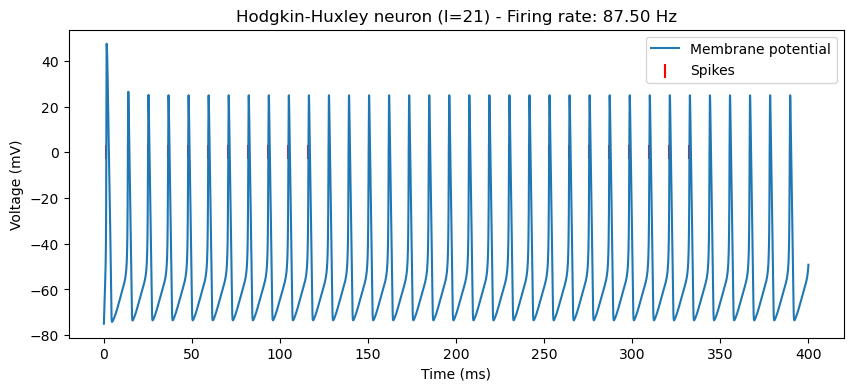

In [56]:
# src/hodgkin_huxley.py

import numpy as np
import matplotlib.pyplot as plt

def alpha_n(V):
    return 0.01*(V+55)/(1-np.exp(-(V+55)/10))

def beta_n(V):
    return 0.125*np.exp(-(V+65)/80)

def alpha_m(V):
    return 0.1*(V+40)/(1-np.exp(-(V+40)/10))

def beta_m(V):
    return 4*np.exp(-(V+65)/18)

def alpha_h(V):
    return 0.07*np.exp(-(V+65)/20)

def beta_h(V):
    return 1/(1+np.exp(-(V+35)/10))


def simulate_hh(T=400, dt=0.01, I_ext=21,
                gNa=120, gK=36, gL=0.3):

    steps = int(T/dt)

    V_rest = -75
    V = V_rest*np.ones(steps)

    #gating variables
    m = np.zeros(steps)
    h = np.zeros(steps)
    n = np.zeros(steps)

    #HH parameters
    Cm = 1
    
    ENa = 50 #potencial de reversion
    EK = -77
    EL = -54.4

    #inicializar agting variables at steady state
    m[0] = alpha_m(V[0])/(alpha_m(V[0])+beta_m(V[0]))
    h[0] = alpha_h(V[0])/(alpha_h(V[0])+beta_h(V[0]))                     
    n[0] = alpha_n(V[0])/(alpha_n(V[0])+beta_n(V[0]))

    spikes = []                      

    for t in range(steps-1):

        an = alpha_n(V[t])
        bn = beta_n(V[t])
        am = alpha_m(V[t])
        bm = beta_m(V[t])
        ah = alpha_h(V[t])
        bh = beta_h(V[t])

        #updating gating variables
        n[t+1] = n[t] + dt*(an*(1-n[t]) - bn*n[t])
        m[t+1] = m[t] + dt*(am*(1-m[t]) - bm*m[t])
        h[t+1] = h[t] + dt*(ah*(1-h[t]) - bh*h[t])

        #ionic currents
        INa = gNa*(m[t]**3)*h[t]*(V[t]-ENa)
        IK = gK*(n[t]**4)*(V[t]-EK)
        IL = gL*(V[t]-EL)

        #HH membrane equation
        dV = (I_ext - INa - IK - IL)/Cm  #ecuacion HH
        V[t+1] = V[t] + dt*dV

        #spike detection
        if V[t] < 0 and V[t+1] >= 0:
            spikes.append(t*dt)

    return V, spikes

##RUN SIMULATION
T = 400
dt = 0.01
I = 21

V_hh, spikes_hh = simulate_hh(T=T, dt=dt, I_ext=I)

#firing rate

T_total_s = T/1000
firing_rate = len(spikes_hh)/T_total_s

print("HH spike times:", spikes_hh)
print("HH spikes:", len(spikes_hh))
print(f"HH firing rate: {firing_rate:.2f} Hz")

#Plot
time = np.arange(0, T, dt)

plt.figure(figsize=(10,4))
plt.plot(time, V_hh, label="Membrane potential")
plt.scatter(spikes_hh, [0]*len(spikes_hh), color='red', marker='|', s=100, label="Spikes")

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title(f"Hodgkin-Huxley neuron (I={I}) - Firing rate: {firing_rate:.2f} Hz")

plt.legend()
plt.show()

**LEAKY INTEGRATE-AND-FIRE MODEL**

Spike times (ms): [10.07, 20.080000000000002, 30.09, 40.1, 50.11, 60.120000000000005, 70.13, 80.14, 90.15, 100.16, 110.17, 120.18, 130.19, 140.20000000000002, 150.21, 160.22, 170.23, 180.24, 190.25, 200.26, 210.27, 220.28, 230.29, 240.3, 250.31, 260.32, 270.33, 280.34000000000003, 290.35, 300.36, 310.37, 320.38, 330.39, 340.40000000000003, 350.41, 360.42, 370.43, 380.44, 390.45]
Spike indices: [1007, 2008, 3009, 4010, 5011, 6012, 7012, 8014, 9015, 10016, 11017, 12018, 13019, 14020, 15021, 16022, 17023, 18024, 19025, 20026, 21027, 22028, 23029, 24030, 25031, 26032, 27032, 28034, 29035, 30036, 31037, 32038, 33039, 34040, 35041, 36042, 37043, 38044, 39045]
Firing rate: 97.50 Hz


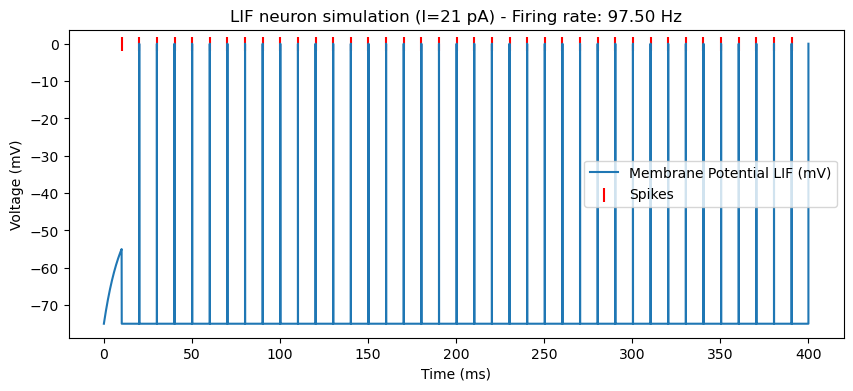

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Función LIF (igual que tu lif_model)
def simulate_lif(T=400, dt=0.01, I=21, 
                 V_rest=-75, V_reset=-75, V_thresh=-55, 
                 tau_m=10, R=1.5, t_ref=10):
    
    steps = int(T/dt)
    
    V = np.zeros(steps)
    V[0] = V_rest
    
    spikes = []
    refrac_counter = 0
    
    for t in range(steps-1):
        
        if refrac_counter > 0:
            V[t] = V_reset
            refrac_counter -= 1
            
        else:
            dV = (-(V[t] - V_rest) + R*I) / tau_m  #ecuacion LIF
            V[t+1] = V[t] + dt*dV
            
            if V[t+1] >= V_thresh:
                spikes.append(t*dt)
                V[t+1] = V_reset
                refrac_counter = int(t_ref/dt)
                
    return V, spikes

# --- Simulación ---
T = 400       # ms
dt = 0.01
I = 21
V_lif, spikes_lif = simulate_lif(T=T, dt=dt, I=I)

# --- Detectar spikes ---
print("Spike times (ms):", spikes_lif)
spike_indices = [int(t/dt) for t in spikes_lif]
print("Spike indices:", spike_indices)

# --- Calcular firing rate ---
T_total_s = T / 1000  # convertir ms a segundos
firing_rate = len(spikes_lif) / T_total_s
print(f"Firing rate: {firing_rate:.2f} Hz")

# --- Ploteo ---
time = np.arange(0, T, dt)

plt.figure(figsize=(10,4))

plt.plot(time, V_lif, label='Membrane Potential LIF (mV)')
plt.scatter(spikes_lif, [0]*len(spikes_lif), color='red', marker='|', s=100, label='Spikes')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title(f'LIF neuron simulation (I={I} pA) - Firing rate: {firing_rate:.2f} Hz')
plt.legend()
plt.show()

Simulación comparativa

**COMPARISON OF HH vs LIF MODELS**

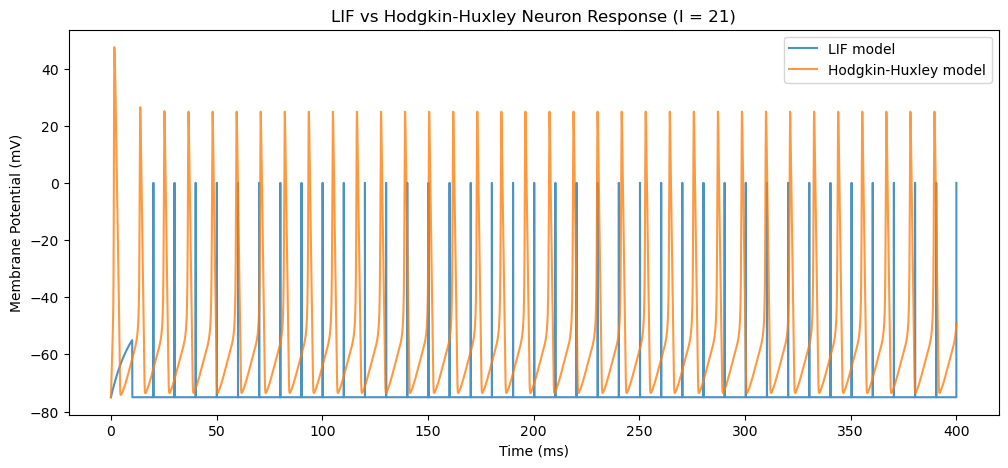

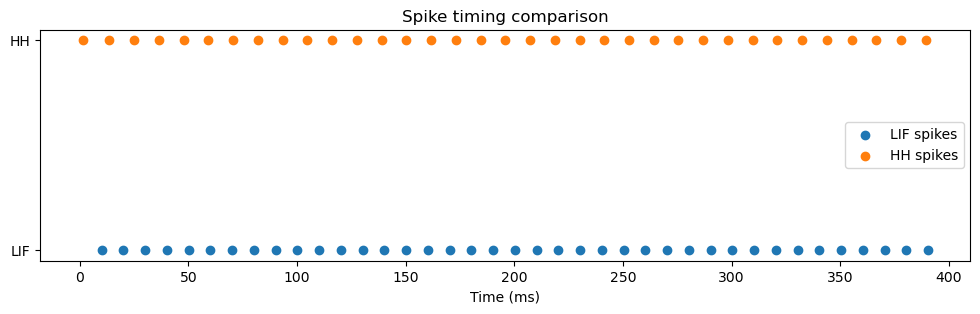

In [57]:
import numpy as np
import matplotlib.pyplot as plt
#correr ambos modelos

V_lif, spikes_lif = simulate_lif(T=400, dt=0.01, I=21)
V_hh, spikes_hh = simulate_hh(T=400, dt=0.01, I_ext=21)

time = np.arange(0, 400, 0.01)

plt.figure(figsize=(12,5))

plt.plot(time, V_lif, label="LIF model", alpha=0.8)
plt.plot(time, V_hh, label="Hodgkin-Huxley model", alpha=0.8)

plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.title("LIF vs Hodgkin-Huxley Neuron Response (I = 21)")
plt.legend()

plt.show()

#comparar spikes
plt.figure(figsize=(12,3))

plt.scatter(spikes_lif, [1]*len(spikes_lif), label="LIF spikes")
plt.scatter(spikes_hh, [2]*len(spikes_hh), label="HH spikes")

plt.yticks([1,2], ["LIF","HH"])
plt.xlabel("Time (ms)")
plt.title("Spike timing comparison")

plt.legend()
plt.show()

**DETECT SPIKES**

In [58]:
# Detectar spikes en Hodgkin-Huxley (cruce por 0 mV)
spikes_hh_idx = np.where((V_hh[:-1] < 0) & (V_hh[1:] >= 0))[0]

# convertir índices a tiempo
spikes_hh = spikes_hh_idx * dt

# LIF ya devuelve los tiempos directamente
spikes_lif = spikes_lif

print("HH spikes:", len(spikes_hh))
print("LIF spikes:", len(spikes_lif))

HH spikes: 35
LIF spikes: 39


**F-I CURVE: LIF vs HH**

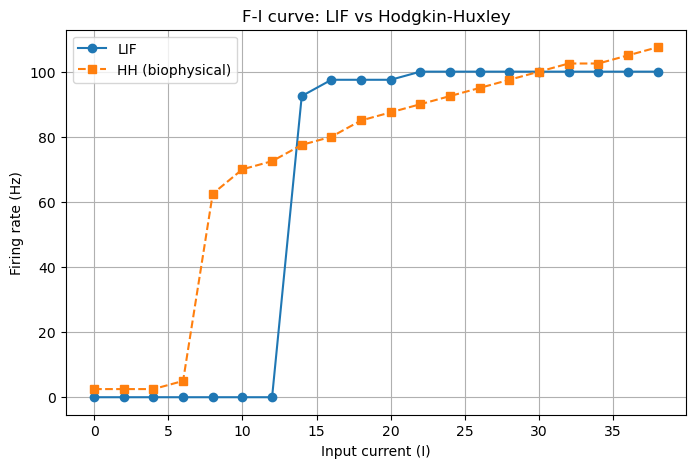

In [59]:
# =========================
# F-I CURVE (LIF vs HH)
# =========================

currents = np.arange(0, 40, 2)
T_total_s = T / 1000

def compute_firing_rate(simulate_func, currents, T, dt):
    rates = []
    
    for I in currents:
        V, spikes = simulate_func(T, dt, I)
        rate = len(spikes) / T_total_s
        rates.append(rate)
        
    return rates

# Calcular rates
rates_lif = compute_firing_rate(simulate_lif, currents, T, dt)
rates_hh = compute_firing_rate(simulate_hh, currents, T, dt)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,5))

plt.plot(currents, rates_lif, marker='o', label="LIF")
plt.plot(currents, rates_hh, marker='s', linestyle='--', label="HH (biophysical)")
plt.xlabel("Input current (I)")
plt.ylabel("Firing rate (Hz)")
plt.title("F-I curve: LIF vs Hodgkin-Huxley")

plt.legend()
plt.grid(True)

plt.show()

**F-I CURVES: LIF**

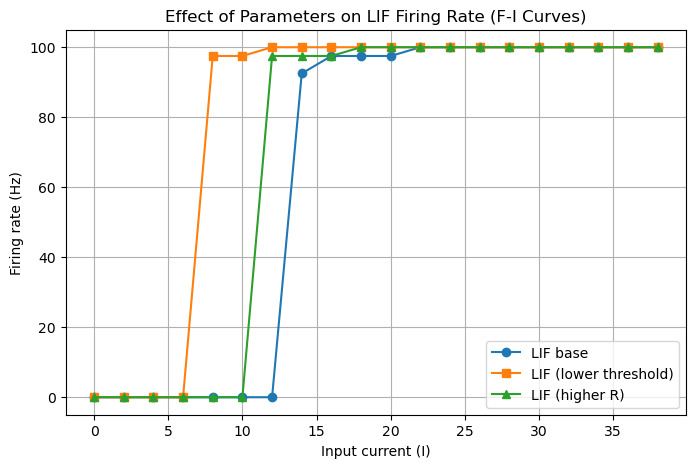

In [63]:
# =========================
# COMPARAR 3 LIF (F-I CURVES)
# =========================

currents = np.arange(0, 40, 2)
T = 400
dt = 0.01
T_seconds = T / 1000

def compute_firing_rate(simulate_func, currents, T, dt, **kwargs):
    rates = []
    for I in currents:
        _, spikes = simulate_func(T, dt, I, **kwargs)
        rate = len(spikes) / T_seconds
        rates.append(rate)
    return rates

# 🔵 LIF base
rates_base = compute_firing_rate(simulate_lif, currents, T, dt)

# 🟢 LIF con threshold más bajo (más excitable)
rates_low_thresh = compute_firing_rate(
    simulate_lif, currents, T, dt,
    V_thresh=-65
)

# 🔴 LIF con mayor resistencia (más sensible a input)
rates_high_R = compute_firing_rate(
    simulate_lif, currents, T, dt,
    R=2
)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,5))

plt.plot(currents, rates_base, marker='o', label="LIF base")
plt.plot(currents, rates_low_thresh, marker='s', label="LIF (lower threshold)")
plt.plot(currents, rates_high_R, marker='^', label="LIF (higher R)")

plt.xlabel("Input current (I)")
plt.ylabel("Firing rate (Hz)")
plt.title("Effect of Parameters on LIF Firing Rate (F-I Curves)")

plt.legend()
plt.grid(True)

plt.show()

**F-I CURVES: HH**

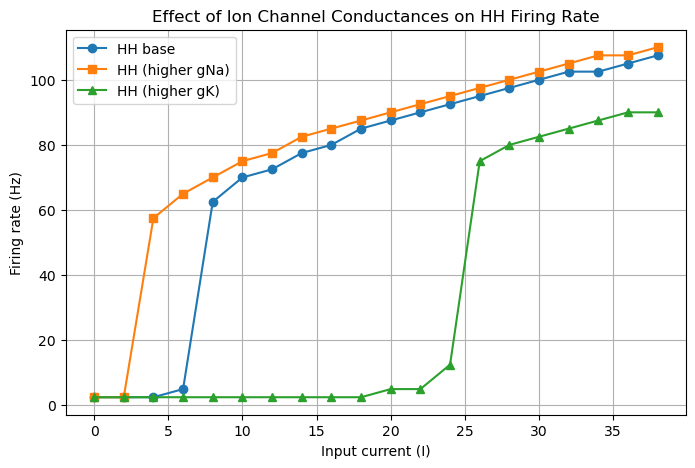

In [61]:
# =========================
# COMPARAR 3 HH (F-I CURVES)
# =========================

currents = np.arange(0, 40, 2)
T = 400
dt = 0.01
T_seconds = T / 1000

def compute_firing_rate(simulate_func, currents, T, dt, **kwargs):
    rates = []
    for I in currents:
        _, spikes = simulate_func(T, dt, I_ext=I, **kwargs)
        rate = len(spikes) / T_seconds
        rates.append(rate)
    return rates

# 🔵 HH base
rates_hh_base = compute_firing_rate(simulate_hh, currents, T, dt)

# 🟢 HH con mayor sodio (más excitabilidad)
rates_high_Na = compute_firing_rate(
    simulate_hh, currents, T, dt,
    gNa=150
)

# 🔴 HH con mayor potasio (más inhibición)
rates_high_K = compute_firing_rate(
    simulate_hh, currents, T, dt,
    gK=50
)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,5))

plt.plot(currents, rates_hh_base, marker='o', label="HH base")
plt.plot(currents, rates_high_Na, marker='s', label="HH (higher gNa)")
plt.plot(currents, rates_high_K, marker='^', label="HH (higher gK)")

plt.xlabel("Input current (I)")
plt.ylabel("Firing rate (Hz)")
plt.title("Effect of Ion Channel Conductances on HH Firing Rate")

plt.legend()
plt.grid(True)

plt.show()

**F-I CURVES: 3 LIF vs 3 HH**

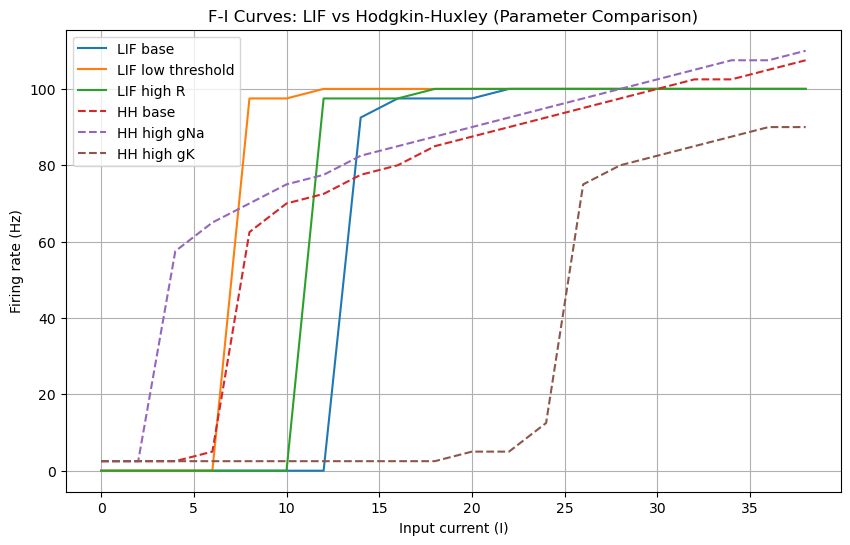

In [65]:
# =========================
# F-I CURVES: LIF vs HH
# =========================

currents = np.arange(0, 40, 2)
T = 400
dt = 0.01
T_seconds = T / 1000

def compute_firing_rate(simulate_func, currents, T, dt, model="lif", **kwargs):
    rates = []
    
    for I in currents:
        if model == "lif":
            _, spikes = simulate_func(T, dt, I, **kwargs)
        elif model == "hh":
            _, spikes = simulate_func(T, dt, I_ext=I, **kwargs)
        
        rate = len(spikes) / T_seconds
        rates.append(rate)
        
    return rates

# =========================
# LIF
# =========================
rates_lif_base = compute_firing_rate(simulate_lif, currents, T, dt, model="lif")
rates_lif_low = compute_firing_rate(simulate_lif, currents, T, dt, model="lif", V_thresh=-65)
rates_lif_highR = compute_firing_rate(simulate_lif, currents, T, dt, model="lif", R=2)

# =========================
# HH
# =========================
rates_hh_base = compute_firing_rate(simulate_hh, currents, T, dt, model="hh")
rates_hh_highNa = compute_firing_rate(simulate_hh, currents, T, dt, model="hh", gNa=150)
rates_hh_highK = compute_firing_rate(simulate_hh, currents, T, dt, model="hh", gK=50)

# =========================
# PLOT
# =========================
plt.figure(figsize=(10,6))

# LIF (líneas sólidas)
plt.plot(currents, rates_lif_base, label="LIF base", linestyle='-')
plt.plot(currents, rates_lif_low, label="LIF low threshold", linestyle='-')
plt.plot(currents, rates_lif_highR, label="LIF high R", linestyle='-')

# HH (líneas punteadas)
plt.plot(currents, rates_hh_base, label="HH base", linestyle='--')
plt.plot(currents, rates_hh_highNa, label="HH high gNa", linestyle='--')
plt.plot(currents, rates_hh_highK, label="HH high gK", linestyle='--')

plt.xlabel("Input current (I)")
plt.ylabel("Firing rate (Hz)")
plt.title("F-I Curves: LIF vs Hodgkin-Huxley (Parameter Comparison)")

plt.legend()
plt.grid(True)

plt.show()